
# Task 3 — Hypothesis Testing for Insurance Risk Analytics

## Objective
This notebook performs statistical hypothesis testing to determine whether significant insurance risk differences exist across:

- Provinces
- Postal Codes
- Gender groups

The analysis supports data-driven insurance pricing and risk segmentation decisions.


In [2]:

# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")


Libraries imported successfully.



# Load Dataset
Make sure your cleaned dataset exists in:

```text
data/cleaned_insurance_data.csv
```


In [3]:

# Load cleaned dataset

df = pd.read_csv("../data/cleaned_insurance_data.csv")

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (10000, 23)


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,1,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,0.000000,2346.0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,4,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,4.234362,-7549.0
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,1,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0.000000,1697.0
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,0,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,5.119831,-9764.0
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,4,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0.000000,2582.0



# Dataset Information


In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  object 
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  object 
 3   Province             10000 non-null  object 
 4   VehicleType          10000 non-null  object 
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  


# Missing Values


In [5]:

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values.head(20)


CustomerID             0
Age                    0
Gender                 0
Province               0
VehicleType            0
AnnualIncome           0
RiskScore              0
AnnualPremium          0
Deductible             0
NCD                    0
PastClaims             0
Claimed                0
ClaimAmount            0
TotalPremium           0
TotalClaims            0
CoverType              0
AutoMake               0
VehicleModel           0
CustomValueEstimate    0
ZipCode                0
dtype: int64


# Feature Engineering

We create important insurance KPIs:

- Loss Ratio
- Margin
- HasClaim


In [6]:

# Create Loss Ratio

df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

# Replace infinite values

df["LossRatio"] = df["LossRatio"].replace([np.inf, -np.inf], np.nan)

# Create Margin

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

# Create Claim Indicator

df["HasClaim"] = (df["TotalClaims"] > 0).astype(int)

df[["LossRatio", "Margin", "HasClaim"]].head()


,LossRatio,Margin,HasClaim
0,0.000000,2346.0,0
1,4.234362,-7549.0,1
2,0.000000,1697.0,0
3,5.119831,-9764.0,1
4,0.000000,2582.0,0



# Descriptive Statistics


In [7]:

df[["TotalPremium", "TotalClaims", "LossRatio", "Margin"]].describe()


,TotalPremium,TotalClaims,LossRatio,Margin
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,2488.127900,1314.188500,0.442770,1173.939400
std,735.674491,3921.864903,1.252813,3742.979999
min,951.000000,0.000000,0.000000,-44594.000000
25%,2028.000000,0.000000,0.000000,1812.000000
50%,2307.000000,0.000000,0.000000,2165.000000
75%,2676.000000,0.000000,0.000000,2504.250000
max,5105.000000,49623.000000,15.895383,5079.000000



# Distribution of Loss Ratio


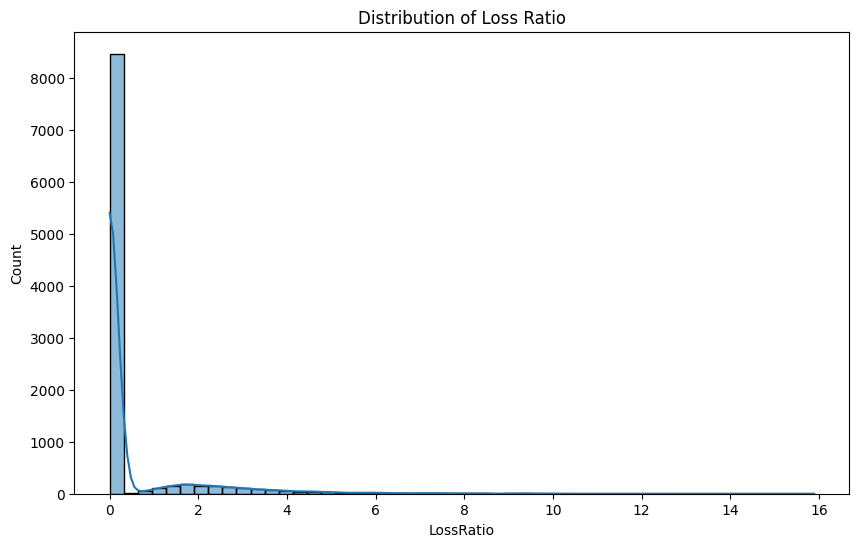

In [8]:

plt.figure(figsize=(10,6))

sns.histplot(df["LossRatio"].dropna(), bins=50, kde=True)

plt.title("Distribution of Loss Ratio")

plt.show()



# Province Risk Comparison

## Hypothesis

### Null Hypothesis (H₀)
There is no significant difference in risk between provinces.

### Alternative Hypothesis (H₁)
There is a significant difference in risk between provinces.


In [9]:

# Check available provinces

df["Province"].value_counts().head(10)


Province
Addis Ababa    3567
Oromia         2446
Amhara         1999
Somali         1184
Tigray          804
Name: count, dtype: int64

In [10]:

# Select top two provinces

top_provinces = df["Province"].value_counts().index[:2]

province_1 = top_provinces[0]
province_2 = top_provinces[1]

print("Province 1:", province_1)
print("Province 2:", province_2)


Province 1: Addis Ababa
Province 2: Oromia


In [11]:

# Extract Loss Ratios

group1 = df[df["Province"] == province_1]["LossRatio"].dropna()

group2 = df[df["Province"] == province_2]["LossRatio"].dropna()

# Perform t-test

stat, p_value = ttest_ind(group1, group2)

print("T-statistic:", stat)
print("P-value:", p_value)


T-statistic: -0.4999554052164896
P-value: 0.6171247791877275


In [12]:

# Decision

if p_value < 0.05:
    print("Reject H0")
    print("There is a statistically significant risk difference between provinces.")
else:
    print("Fail to Reject H0")
    print("No statistically significant risk difference detected.")


Fail to Reject H0
No statistically significant risk difference detected.



# Province Loss Ratio Visualization


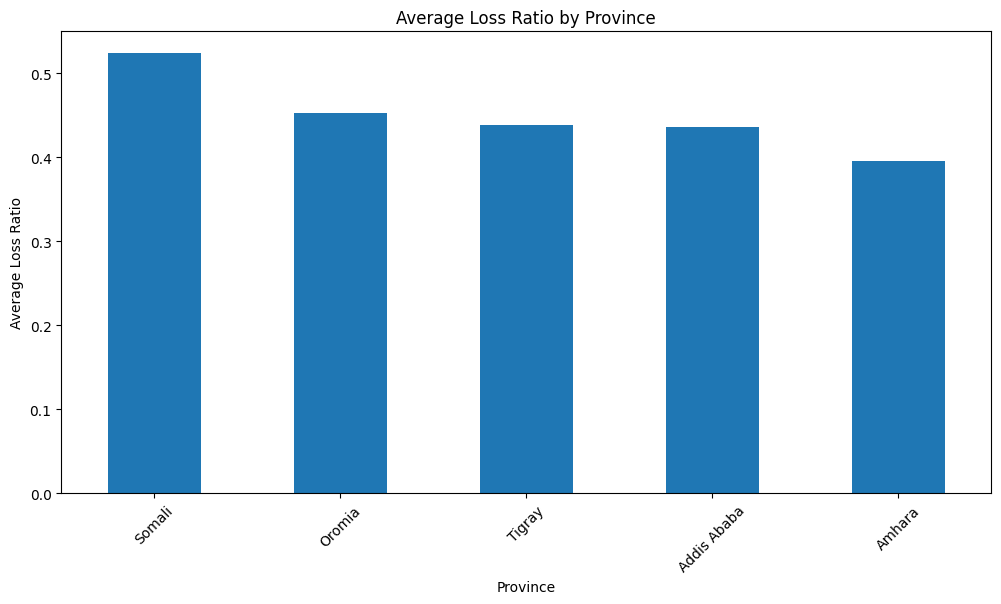

In [13]:

province_risk = df.groupby("Province")["LossRatio"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

province_risk.plot(kind="bar")

plt.title("Average Loss Ratio by Province")

plt.ylabel("Average Loss Ratio")

plt.xticks(rotation=45)

plt.show()



# Postal Code Claim Frequency Test

## Hypothesis

### H₀
There is no significant difference in claim frequency across postal codes.

### H₁
There is a significant difference in claim frequency across postal codes.


In [ ]:

# Create contingency table
postal_table = pd.crosstab(df["PostalCode"], df["HasClaim"])

postal_table.head()


KeyError: 'PostalCode'

In [ ]:

# Chi-square test

chi2, p_value_zip, dof, expected = chi2_contingency(postal_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p_value_zip)


In [ ]:

# Decision

if p_value_zip < 0.05:
    print("Reject H0")
    print("Claim frequency differs significantly across postal codes.")
else:
    print("Fail to Reject H0")
    print("No statistically significant difference detected.")



# Margin Difference Across Postal Codes


In [ ]:

# Select top two postal codes

top_postal = df["PostalCode"].value_counts().index[:2]

zip1 = top_postal[0]
zip2 = top_postal[1]

print("Postal Code 1:", zip1)
print("Postal Code 2:", zip2)


In [ ]:

# Extract margin groups

margin1 = df[df["PostalCode"] == zip1]["Margin"].dropna()

margin2 = df[df["PostalCode"] == zip2]["Margin"].dropna()

# Run t-test

stat_margin, p_margin = ttest_ind(margin1, margin2)

print("T-statistic:", stat_margin)
print("P-value:", p_margin)


In [ ]:

# Decision

if p_margin < 0.05:
    print("Reject H0")
    print("Margins differ significantly between postal codes.")
else:
    print("Fail to Reject H0")
    print("No statistically significant margin difference detected.")



# Gender-Based Risk Analysis

## Hypothesis

### H₀
There is no significant risk difference between genders.

### H₁
There is a significant risk difference between genders.


In [ ]:

# Check gender values

df["Gender"].value_counts()


In [ ]:

# Extract male and female loss ratios

male = df[df["Gender"] == "Male"]["LossRatio"].dropna()

female = df[df["Gender"] == "Female"]["LossRatio"].dropna()

# Perform t-test

gender_stat, gender_p = ttest_ind(male, female)

print("T-statistic:", gender_stat)
print("P-value:", gender_p)


In [ ]:

# Decision

if gender_p < 0.05:
    print("Reject H0")
    print("There is a statistically significant gender risk difference.")
else:
    print("Fail to Reject H0")
    print("No statistically significant gender risk difference detected.")



# Gender Risk Visualization


In [ ]:

gender_risk = df.groupby("Gender")["LossRatio"].mean()

plt.figure(figsize=(6,5))

gender_risk.plot(kind="bar")

plt.title("Average Loss Ratio by Gender")

plt.ylabel("Average Loss Ratio")

plt.show()



# Hypothesis Testing Summary


In [ ]:

summary = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Postal Code Claim Frequency",
        "Postal Code Margin Difference",
        "Gender Risk Difference"
    ],
    "P-Value": [
        p_value,
        p_value_zip,
        p_margin,
        gender_p
    ]
})

summary["Decision"] = summary["P-Value"].apply(
    lambda x: "Reject H0" if x < 0.05 else "Fail to Reject H0"
)

summary



# Business Insights

## Key Findings

- Statistical testing helps identify high-risk customer segments.
- Provinces with higher loss ratios may require premium adjustments.
- Postal codes with high claim frequency may indicate geographic risk concentration.
- Gender-based analysis supports fairness and risk assessment evaluation.

## Business Recommendation

AlphaCare Insurance Solutions can use these findings to:

- Improve pricing strategies
- Optimize underwriting policies
- Reduce insurance losses
- Improve profitability
